## Imports

In [108]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [109]:
df=pd.read_csv(r"C:\Users\Sakshi\Desktop\Finance analyzer\data\transactions.csv")


In [110]:
df.head()

,Date,Description,Amount
0,2025-01-01,Salary,38751
1,2025-01-01,Electricity Bill,-2311
2,2025-01-01,Book Purchase,-1096
3,2025-01-02,Amazon,-2096
4,2025-01-02,Uber,-348


In [111]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         1000 non-null   str  
 1   Description  1000 non-null   str  
 2   Amount       1000 non-null   int64
dtypes: int64(1), str(2)
memory usage: 23.6 KB


In [112]:
df.describe()

,Amount
count,1000.000000
mean,2402.575000
std,10294.191858
min,-2999.000000
25%,-851.250000
50%,-466.500000
75%,-202.750000
max,44823.000000


In [113]:
df.shape

(1000, 3)

## Data Cleaning

In [114]:
df["Date"] = pd.to_datetime(df["Date"])


In [115]:
df.isnull().sum()

Date           0
Description    0
Amount         0
dtype: int64

In [116]:
df.dropna(inplace=True)

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df.drop_duplicates(inplace=True)

## Feature Engineering

In [119]:
df["Month"] = df["Date"].dt.month_name()

In [120]:
df["Year"] = df["Date"].dt.year

In [121]:
df["Day"] = df["Date"].dt.day_name()

In [122]:
df.head()

,Date,Description,Amount,Month,Year,Day
0,2025-01-01,Salary,38751,January,2025,Wednesday
1,2025-01-01,Electricity Bill,-2311,January,2025,Wednesday
2,2025-01-01,Book Purchase,-1096,January,2025,Wednesday
3,2025-01-02,Amazon,-2096,January,2025,Thursday
4,2025-01-02,Uber,-348,January,2025,Thursday


## Categorization

In [123]:
categories = {
    "Zomato":"Food",
    "Swiggy":"Food",
    "Uber":"Transport",
    "Metro":"Transport",
    "Amazon":"Shopping",
    "Netflix":"Entertainment",
    "Salary":"Income",
    "Medicine":"Healthcare",
    "Book Purchase":"Education",
    "Electricity Bill":"Household"
}

## Mapping

In [124]:

df["Category"] = df["Description"].map(categories)

In [125]:
df.head()

,Date,Description,Amount,Month,Year,Day,Category
0,2025-01-01,Salary,38751,January,2025,Wednesday,Income
1,2025-01-01,Electricity Bill,-2311,January,2025,Wednesday,Household
2,2025-01-01,Book Purchase,-1096,January,2025,Wednesday,Education
3,2025-01-02,Amazon,-2096,January,2025,Thursday,Shopping
4,2025-01-02,Uber,-348,January,2025,Thursday,Transport


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1000 non-null   datetime64[us]
 1   Description  1000 non-null   str           
 2   Amount       1000 non-null   int64         
 3   Month        1000 non-null   str           
 4   Year         1000 non-null   int32         
 5   Day          1000 non-null   str           
 6   Category     1000 non-null   str           
dtypes: datetime64[us](1), int32(1), int64(1), str(4)
memory usage: 50.9 KB


In [127]:
df.isnull().sum()

Date           0
Description    0
Amount         0
Month          0
Year           0
Day            0
Category       0
dtype: int64

In [128]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

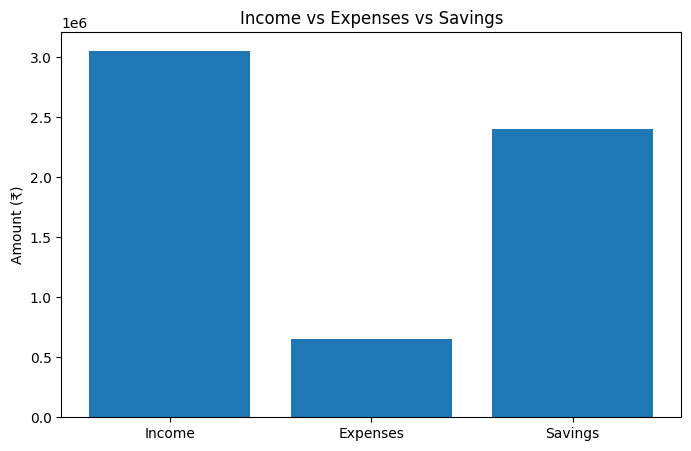

In [129]:
#Total Income VS Total Expenses
income = df[df["Amount"] > 0]["Amount"].sum()
expenses = abs(df[df["Amount"] < 0]["Amount"].sum())
savings = income - expenses

labels = ["Income", "Expenses", "Savings"]
values = [income, expenses, savings]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Income vs Expenses vs Savings")
plt.ylabel("Amount (₹)")
plt.show()

In [130]:
#Spending By Category
expense_df = df[df["Amount"] < 0]
category_spend = (
    expense_df.groupby("Category")["Amount"]
    .sum()
    .abs()
    .sort_values(ascending=False)
)

category_spend

Category
Household        164795
Shopping         160077
Food              83755
Healthcare        78227
Education         64117
Entertainment     52936
Transport         47594
Name: Amount, dtype: int64

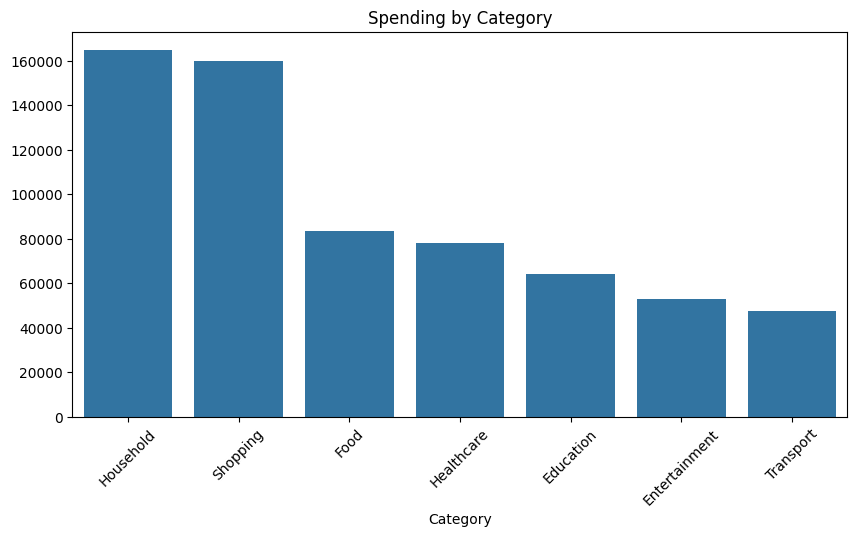

In [131]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_spend.index,
    y=category_spend.values
)

plt.title("Spending by Category")
plt.xticks(rotation=45)
plt.show()

In [132]:
monthly_spend = (
    expense_df.groupby("Month")["Amount"]
    .sum()
    .abs()
)
monthly_spend

Month
April        43803
August       52210
December     53102
February     59316
January      61206
July         56599
June         49676
March        48609
May          68844
November     53973
October      66575
September    37588
Name: Amount, dtype: int64

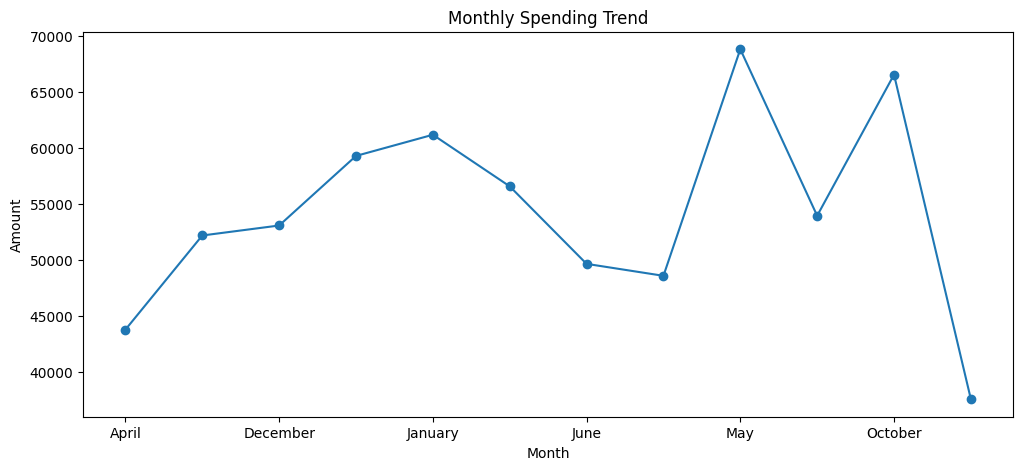

In [133]:
plt.figure(figsize=(12,5))

monthly_spend.plot(marker="o")

plt.title("Monthly Spending Trend")
plt.ylabel("Amount")
plt.show()

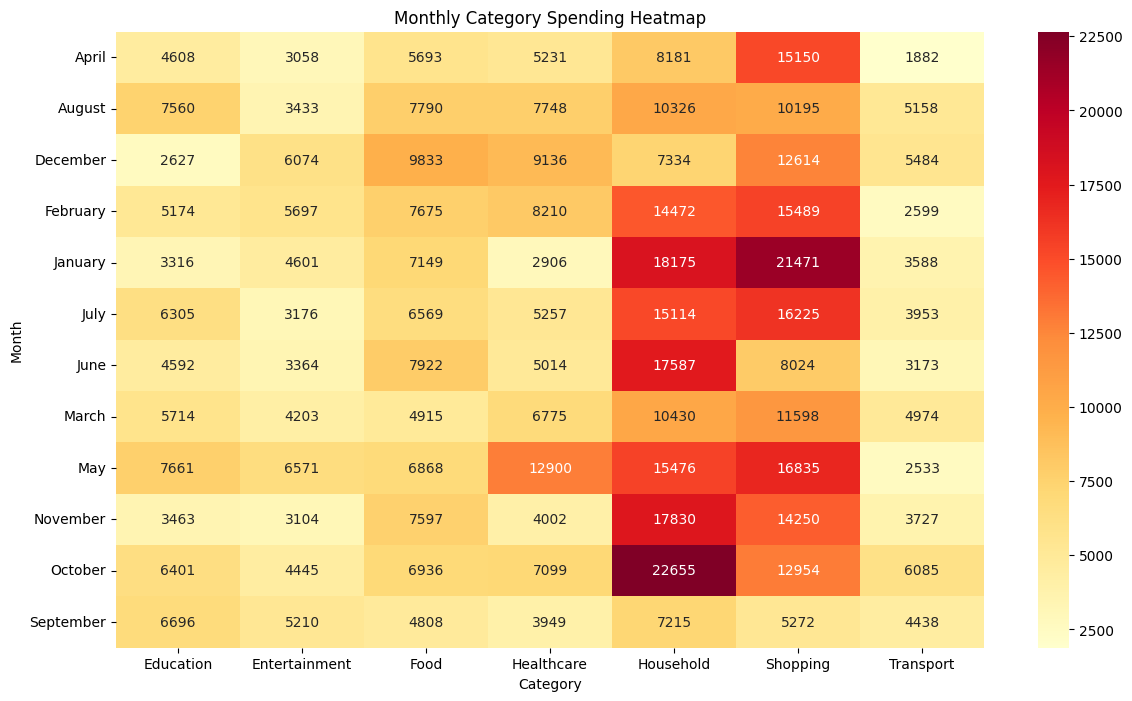

In [134]:
#Monthly Category Spending
heatmap_data = pd.pivot_table(
    expense_df,
    values="Amount",
    index="Month",
    columns="Category",
    aggfunc="sum"
)

heatmap_data = heatmap_data.abs()
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Monthly Category Spending Heatmap")

plt.show()

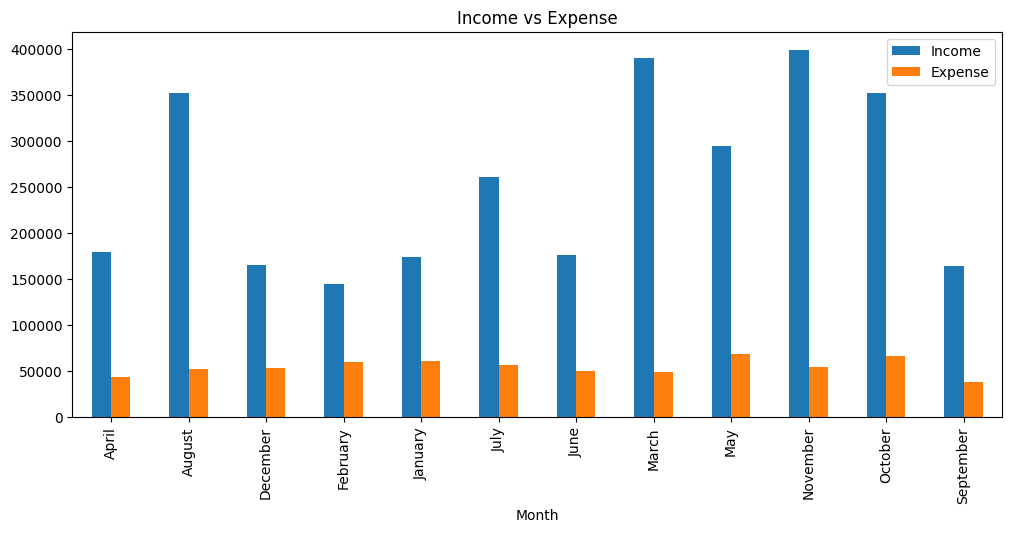

In [135]:
#Monthly Income VS Expenses
monthly_income = (
    df[df["Amount"] > 0]
    .groupby("Month")["Amount"]
    .sum()
)

monthly_expense = (
    abs(
        df[df["Amount"] < 0]
        .groupby("Month")["Amount"]
        .sum()
    )
)
comparison = pd.DataFrame({
    "Income": monthly_income,
    "Expense": monthly_expense
})

comparison

comparison.plot(kind="bar", figsize=(12,5))

plt.title("Income vs Expense")
plt.show()

In [136]:
comparison["Savings"] = (
    comparison["Income"] - comparison["Expense"]
)

comparison["Savings Rate"] = (
    comparison["Savings"] /
    comparison["Income"] * 100
)
comparison

,Income,Expense,Savings,Savings Rate
Month,,,,
April,179736,43803,135933,75.629256
August,352700,52210,300490,85.197051
December,165256,53102,112154,67.866825
February,144964,59316,85648,59.082255
January,174123,61206,112917,64.848986
July,261336,56599,204737,78.342440
June,176014,49676,126338,71.777245
March,390272,48609,341663,87.544841
May,294454,68844,225610,76.619778


In [137]:
comparison["Savings Rate"].mean()

np.float64(75.96189067566162)

In [138]:
expense_df.loc[
    expense_df["Amount"].idxmin()
]

Date           2025-07-09 00:00:00
Description                 Amazon
Amount                       -2999
Month                         July
Year                          2025
Day                      Wednesday
Category                  Shopping
Name: 493, dtype: object

78.66781966133128


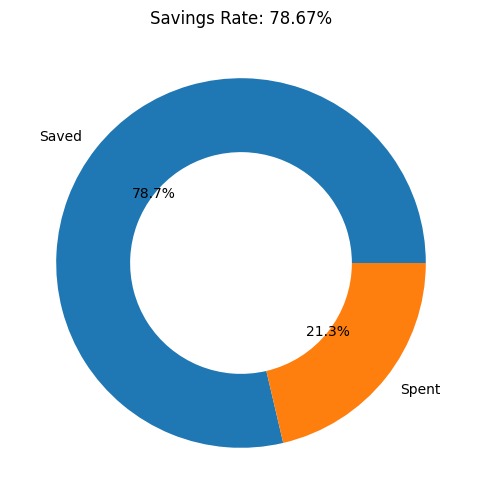

In [139]:
total_income = df[df["Amount"] > 0]["Amount"].sum()

total_expense = abs(
    df[df["Amount"] < 0]["Amount"].sum()
)

savings_rate = (
    (total_income - total_expense)
    / total_income
) * 100

print(savings_rate)
plt.figure(figsize=(6,6))

plt.pie(
    [savings, total_expense],
    labels=["Saved", "Spent"],
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title(f"Savings Rate: {savings_rate:.2f}%")

plt.show()

12.855697842367086


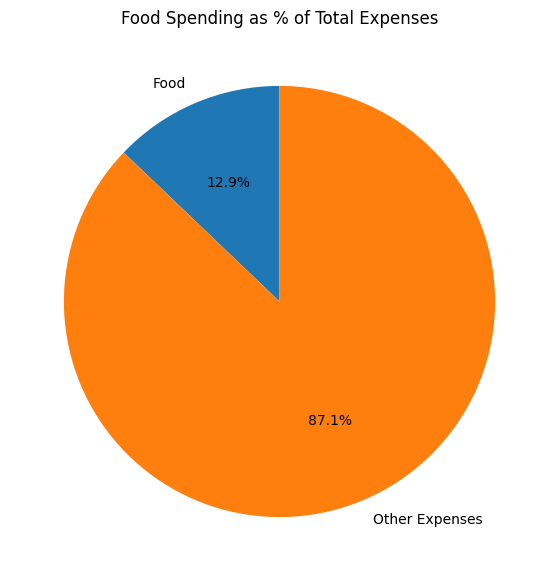

Food accounts for 12.86% of total expenses.


In [140]:
#Food spending percentage
food_spend = abs(
    expense_df[
        expense_df["Category"] == "Food"
    ]["Amount"].sum()
)

food_percentage = (
    food_spend / total_expense
) * 100

print(food_percentage)
other_expenses = total_expense - food_spend

plt.figure(figsize=(7,7))

plt.pie(
    [food_spend, other_expenses],
    labels=["Food", "Other Expenses"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Food Spending as % of Total Expenses")

plt.show()
print(f"Food accounts for {food_percentage:.2f}% of total expenses.")

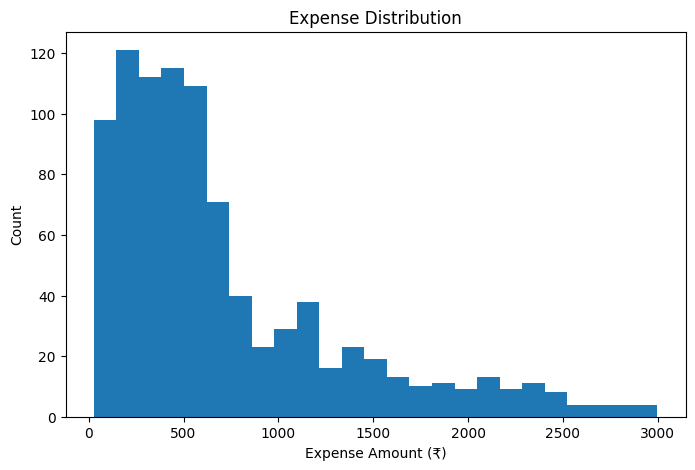

In [141]:
expense_amounts = abs(df[df["Amount"] < 0]["Amount"])

plt.figure(figsize=(8,5))
plt.hist(expense_amounts, bins=25)

plt.title("Expense Distribution")
plt.xlabel("Expense Amount (₹)")
plt.ylabel("Count")
plt.show()

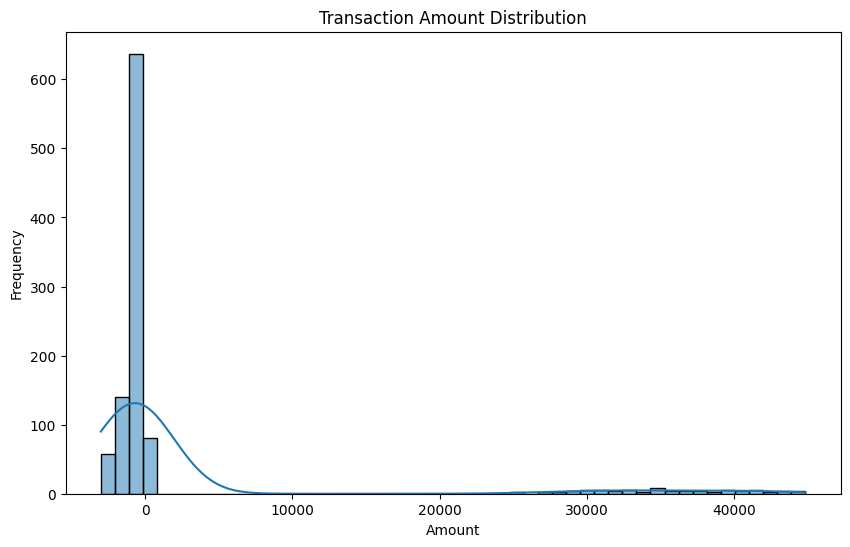

In [142]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

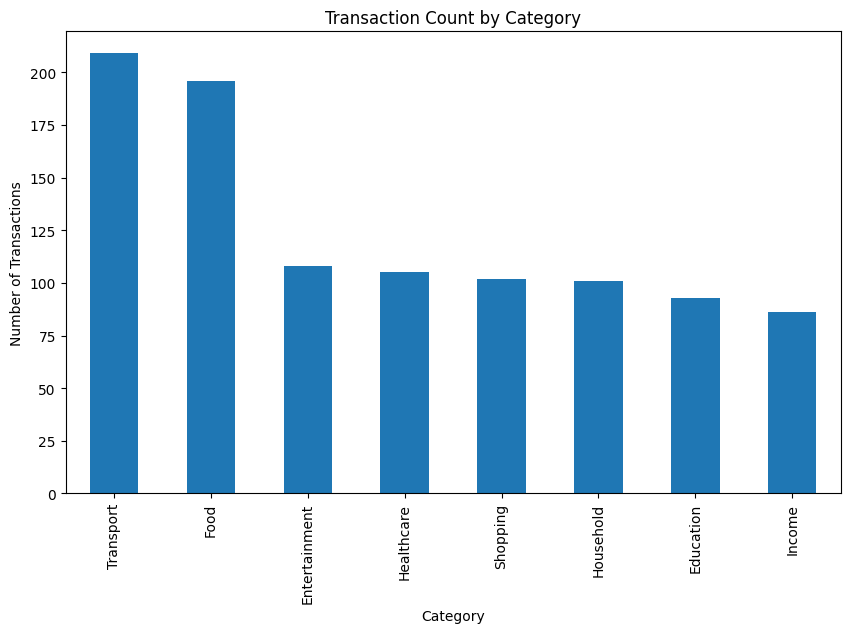

In [143]:
plt.figure(figsize=(10,6))

df["Category"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.show()

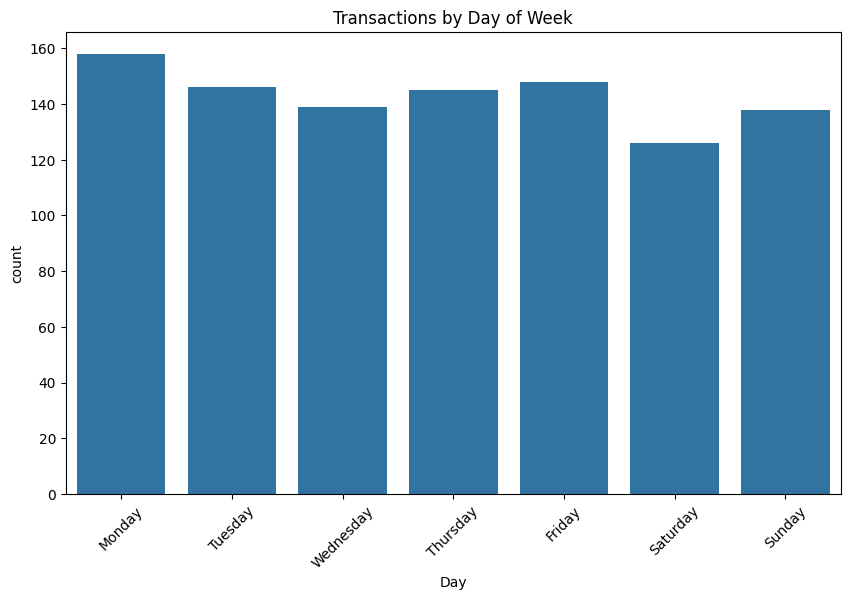

In [144]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Day",
    order=day_order
)

plt.title("Transactions by Day of Week")

plt.xticks(rotation=45)

plt.show()

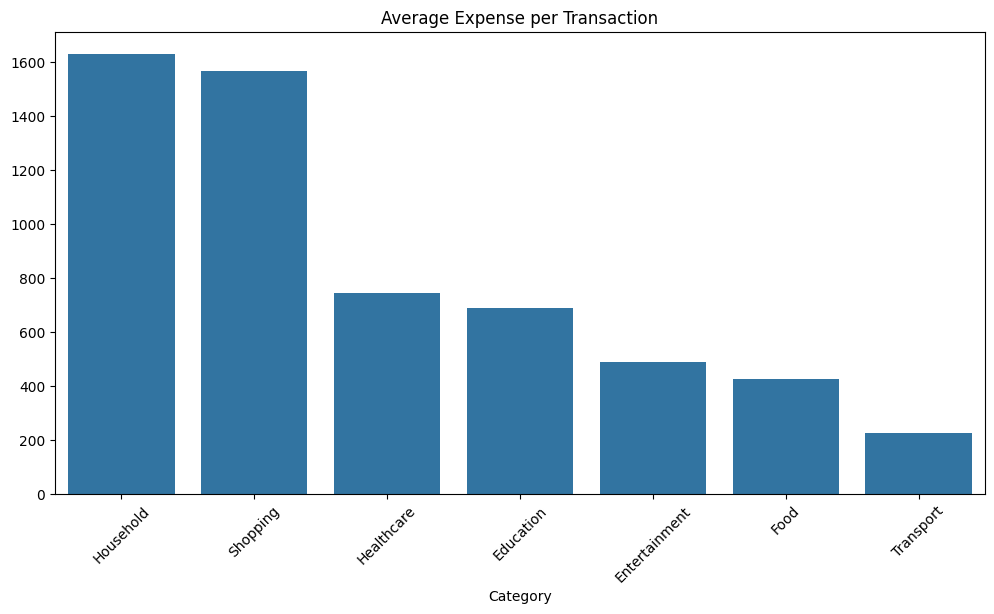

In [145]:
avg_transaction = (
    expense_df.groupby("Category")["Amount"]
    .mean()
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_transaction.index,
    y=avg_transaction.values
)

plt.title("Average Expense per Transaction")

plt.xticks(rotation=45)

plt.show()

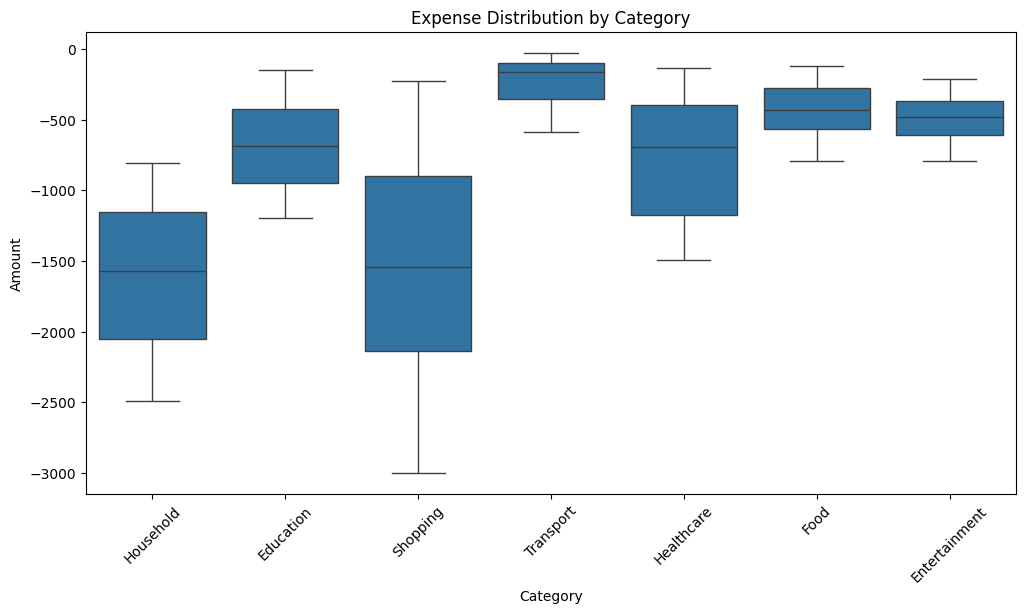

In [146]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=expense_df,
    x="Category",
    y="Amount"
)

plt.xticks(rotation=45)

plt.title("Expense Distribution by Category")

plt.show()

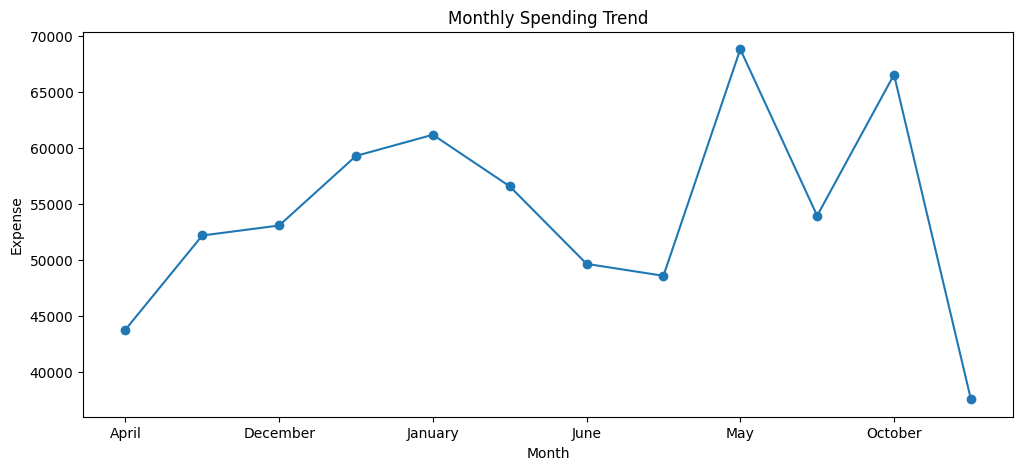

In [147]:
#Time series analysis
monthly_spend = (
    expense_df.groupby("Month")["Amount"]
    .sum()
    .abs()
)

monthly_spend.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Spending Trend")

plt.ylabel("Expense")

plt.show()

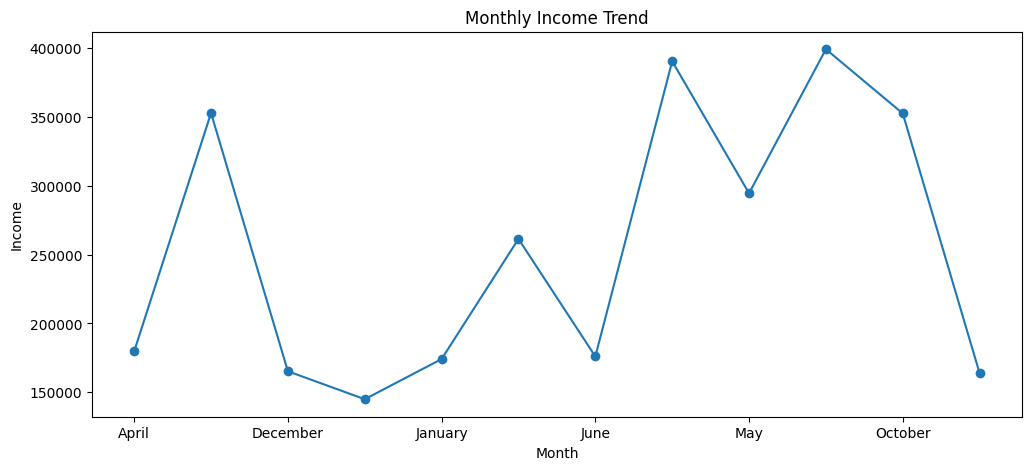

In [148]:
#Monthly Income Trend
income_df = df[df["Amount"] > 0]

monthly_income = (
    income_df.groupby("Month")["Amount"]
    .sum()
)

monthly_income.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Income Trend")

plt.ylabel("Income")

plt.show()

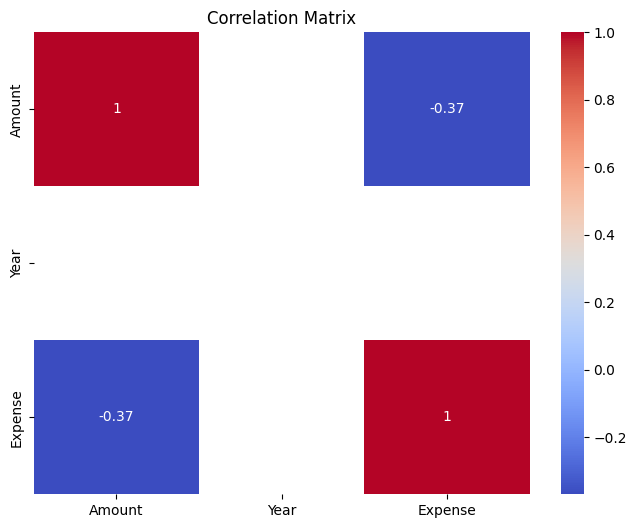

In [149]:
df["Expense"] = np.where(
    df["Amount"] < 0,
    abs(df["Amount"]),
    0
)
numeric_df = df.select_dtypes(
    include=np.number
)

numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Insights and recommendation

In [150]:
highest_category = category_spend.idxmax()

highest_amount = category_spend.max()

print(
    f"Highest spending category is "
    f"{highest_category} "
    f"with ₹{highest_amount:,.0f}"
)

Highest spending category is Household with ₹164,795


In [151]:
lowest_category = category_spend.idxmin()

print(
    f"Lowest spending category is "
    f"{lowest_category}"
)

Lowest spending category is Transport


In [152]:
best_month = comparison["Savings"].idxmax()

print(
    f"Best savings month was "
    f"{best_month}"
)

Best savings month was November


In [153]:
worst_month = comparison["Savings"].idxmin()

print(
    f"Worst savings month was "
    f"{worst_month}"
)

Worst savings month was February


In [154]:
if food_percentage > 30:
    print(
        "Warning: Food expenses exceed "
        "30% of total spending."
    )

In [155]:
#Emergency Funds
monthly_average_expense = (
    total_expense / 12
)

emergency_fund = (
    monthly_average_expense * 6
)

print(
    f"Recommended emergency fund: "
    f"₹{emergency_fund:,.0f}"
)

Recommended emergency fund: ₹325,750


In [163]:
avg_category_spend = (
    expense_df
    .groupby("Category")
    ["Amount"]
    .mean()
    .abs()
)
for category, amount in avg_category_spend.items():

    recommended = amount * 0.9

    print(
        f"{category}: "
        f"Current Avg ₹{amount:.0f} | "
        f"Recommended ₹{recommended:.0f}"
    )

Education: Current Avg ₹689 | Recommended ₹620
Entertainment: Current Avg ₹490 | Recommended ₹441
Food: Current Avg ₹427 | Recommended ₹385
Healthcare: Current Avg ₹745 | Recommended ₹671
Household: Current Avg ₹1632 | Recommended ₹1468
Shopping: Current Avg ₹1569 | Recommended ₹1412
Transport: Current Avg ₹228 | Recommended ₹205


In [156]:
monthly_expenses = (
    expense_df.groupby("Month")["Amount"]
    .sum()
    .abs()
)
expense_mean = monthly_expenses.mean()

expense_std = monthly_expenses.std()

stability_score = (
    100 -
    ((expense_std / expense_mean) * 100)
)

stability_score = max(
    0,
    min(100, stability_score)
)

print(stability_score)

83.43687142455943


In [157]:
health_score = (
    0.5 * savings_rate +
    0.3 * stability_score +
    0.2 * (100 - food_percentage)
)

health_score = round(
    max(0, min(100, health_score)),
    2
)

print(
    f"Financial Health Score: "
    f"{health_score}/100"
)

Financial Health Score: 81.79/100


## Anomalies

In [159]:
#Large Expenses
mean_expense = (
    expense_df["Amount"]
    .mean()
)

std_expense = (
    expense_df["Amount"]
    .std()
)
threshold = (
    mean_expense -
    (2 * std_expense)
)

In [160]:
anomalies = expense_df[
    expense_df["Amount"]
    < threshold
]
anomalies[
    [
        "Date",
        "Description",
        "Amount",
        "Category"
    ]
]

,Date,Description,Amount,Category
1,2025-01-01,Electricity Bill,-2311,Household
3,2025-01-02,Amazon,-2096,Shopping
10,2025-01-07,Electricity Bill,-2395,Household
15,2025-01-09,Amazon,-2394,Shopping
36,2025-01-17,Electricity Bill,-2059,Household
...,...,...,...,...
932,2025-12-06,Amazon,-2277,Shopping
939,2025-12-08,Amazon,-2917,Shopping
953,2025-12-13,Electricity Bill,-1997,Household
960,2025-12-16,Amazon,-2825,Shopping


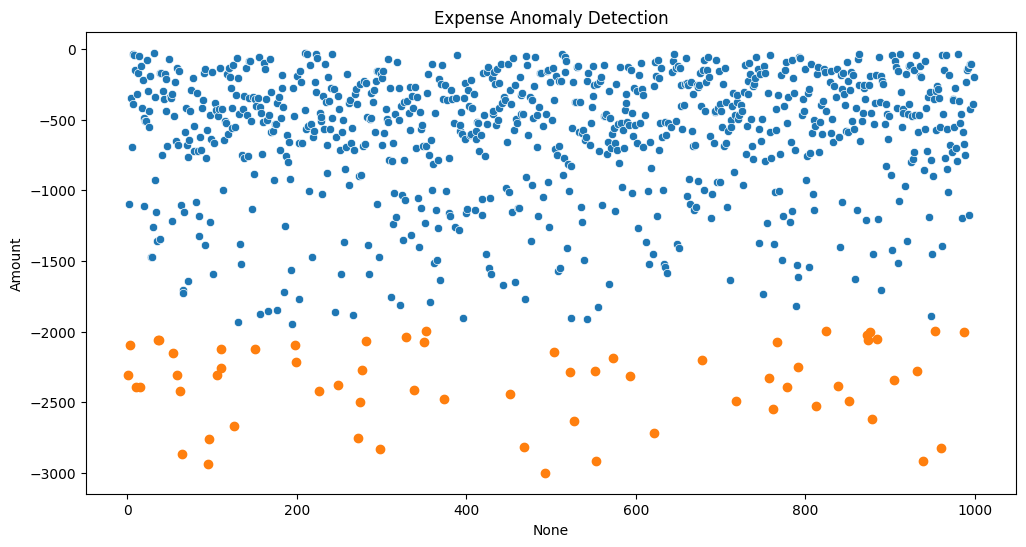

In [161]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=expense_df.index,
    y=expense_df["Amount"]
)

plt.scatter(
    anomalies.index,
    anomalies["Amount"]
)

plt.title(
    "Expense Anomaly Detection"
)

plt.show()